#  Análisis Exploratorio de Datos: YouTube Trending

---

## Descripción del Proyecto

Este proyecto analiza el comportamiento de los videos en tendencia (*trending*) en YouTube durante el período comprendido entre el **14 de noviembre de 2017** y el **14 de junio de 2018**, abarcando un total de **8 meses** de actividad en la plataforma.

El dataset `trending_by_time.csv` registra, para cada combinación de **región**, **fecha** y **categoría de contenido**, el número de videos que lograron posicionarse en la sección de Trending de YouTube. Con **12.343 registros** y **5 columnas**, la tabla permite estudiar patrones de consumo y preferencias de contenido en distintos mercados a nivel global.

###  Regiones analizadas
- Francia · India · Japón · Rusia · Estados Unidos

###  Categorías de contenido
18 categorías, entre ellas: Entertainment, Music, News & Politics, People & Blogs, Gaming, Sports, y más.

###  Objetivos del análisis
1. Inspeccionar y limpiar el dataset para garantizar su calidad.
2. Identificar las categorías de contenido con mayor presencia en Trending globalmente.
3. Comparar el volumen de actividad entre regiones.
4. Explorar la evolución temporal del trending mes a mes.
5. Detectar preferencias locales por categoría en cada región.
6. Entender la distribución estadística de la variable `videos_count`.

---

## 1. Carga e Inspección Inicial

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración visual general
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})

# Carga de datos
df = pd.read_csv('trending_by_time.csv')
print('Vista inicial de los datos:')
print()
df.info()
print()
df.head()

Vista inicial de los datos:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12343 entries, 0 to 12342
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   record_id       12343 non-null  int64 
 1   region          12343 non-null  object
 2   trending_date   12343 non-null  object
 3   category_title  12343 non-null  object
 4   videos_count    12343 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 482.3+ KB



,record_id,region,trending_date,category_title,videos_count
0,1,France,2017-11-14,Autos & Vehicles,8
1,2,France,2017-11-15,Autos & Vehicles,2
2,3,France,2017-11-16,Autos & Vehicles,6
3,4,France,2017-11-17,Autos & Vehicles,8
4,5,France,2017-11-18,Autos & Vehicles,4


###  Observaciones iniciales

- El dataset contiene **12.343 registros** sin valores nulos en ninguna columna, lo que indica que los datos están completos.
- Todas las columnas tienen tipos de datos coherentes con su contenido, con una excepción: `trending_date` está almacenada como `object` (texto) y debe convertirse a `datetime64` para facilitar el análisis temporal.
- Los datos están bien estructurados y organizados por combinación de región, fecha y categoría.

---
## 2. Limpieza y Preprocesamiento

In [2]:
# Convertir trending_date a datetime
df['trending_date'] = pd.to_datetime(df['trending_date'])

# Eliminar espacios en blanco en columnas de texto
df['region'] = df['region'].str.strip()
df['category_title'] = df['category_title'].str.strip()

# Verificar duplicados
duplicados = df.duplicated().sum()
print(f'Registros duplicados: {duplicados}')

# Verificar valores únicos en columnas categóricas
print(f'Regiones únicas: {sorted(df["region"].unique())}')
print(f'Categorías únicas ({df["category_title"].nunique()}): {sorted(df["category_title"].unique())}')

# Crear columna auxiliar de mes para análisis temporal
df['month'] = df['trending_date'].dt.to_period('M')

print()
print(' Preprocesamiento completado. Estado final:')
print()
df.info()

Registros duplicados: 0
Regiones únicas: ['France', 'India', 'Japan', 'Russia', 'United States']
Categorías únicas (18): ['Autos & Vehicles', 'Comedy', 'Education', 'Entertainment', 'Film & Animation', 'Gaming', 'Howto & Style', 'Movies', 'Music', 'News & Politics', 'Nonprofits & Activism', 'People & Blogs', 'Pets & Animals', 'Science & Technology', 'Shows', 'Sports', 'Trailers', 'Travel & Events']

 Preprocesamiento completado. Estado final:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12343 entries, 0 to 12342
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   record_id       12343 non-null  int64         
 1   region          12343 non-null  object        
 2   trending_date   12343 non-null  datetime64[ns]
 3   category_title  12343 non-null  object        
 4   videos_count    12343 non-null  int64         
 5   month           12343 non-null  period[M]     
dtypes: datetime64[ns](1), i

###  Resultado del preprocesamiento

- No se encontraron registros duplicados: los 12.343 registros son únicos.
- No existen valores atípicos ni inconsistencias en los campos categóricos: los nombres de regiones y categorías son uniformes.
- La columna `trending_date` fue convertida exitosamente a `datetime64`, lo que habilita el análisis temporal.
- Se creó la columna auxiliar `month` para facilitar las agrupaciones mensuales.
- **Conclusión:** el dataset estaba en buenas condiciones desde el origen. Los ajustes realizados son de forma, no de fondo, y se procede con confianza al análisis.

---
## 3. Resumen Estadístico General

In [3]:
print(' Estadísticas de videos_count')
print('='*40)
print(df['videos_count'].describe().round(2).to_string())
print()
print(f' Período: {df["trending_date"].min().date()} → {df["trending_date"].max().date()}')
print()
print(' Total de videos en tendencia por región')
print('='*40)
region_total = df.groupby('region')['videos_count'].sum().sort_values(ascending=False)
print(region_total.to_string())
print()
print(' Top 10 categorías por volumen total')
print('='*40)
cat_total = df.groupby('category_title')['videos_count'].sum().sort_values(ascending=False)
print(cat_total.head(10).to_string())

 Estadísticas de videos_count
count    12343.00
mean        27.55
std         29.79
min          2.00
25%          8.00
50%         18.00
75%         36.00
max        220.00

 Período: 2017-11-14 → 2018-06-14

 Total de videos en tendencia por región
region
United States    80758
France           75404
Russia           73694
India            73372
Japan            36762

 Top 10 categorías por volumen total
category_title
Entertainment           95008
People & Blogs          44700
Music                   34390
News & Politics         34202
Comedy                  29470
Sports                  20966
Howto & Style           20124
Film & Animation        19562
Science & Technology     9932
Education                8662


---
## 4. ¿Qué categorías dominan el Trending global?

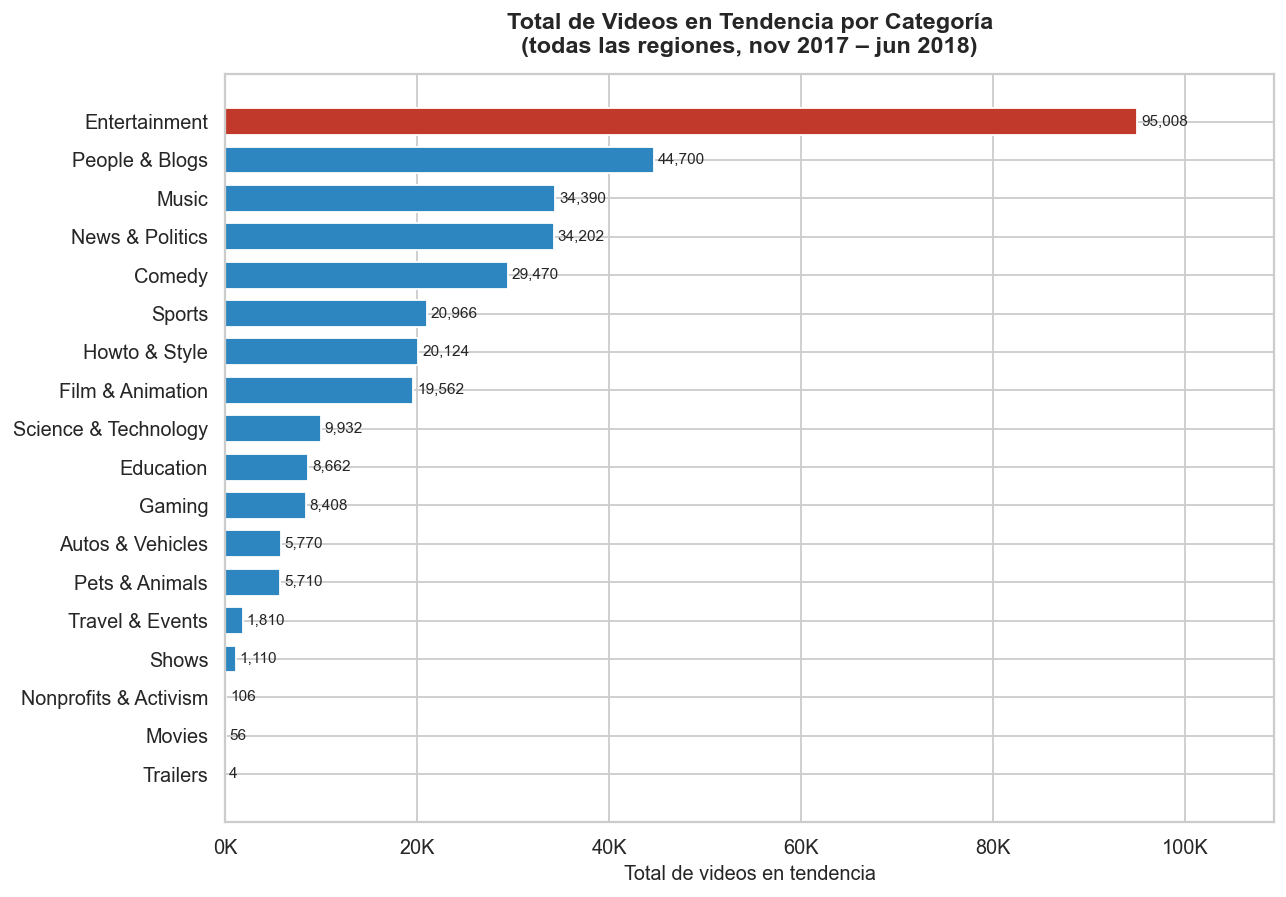

In [4]:
cat_total = df.groupby('category_title')['videos_count'].sum().sort_values()
colors = ['#c0392b' if v == cat_total.max() else '#2e86c1' for v in cat_total.values]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(cat_total.index, cat_total.values, color=colors, edgecolor='white', height=0.7)
for i, v in enumerate(cat_total.values):
    ax.text(v + 400, i, f'{v:,.0f}', va='center', fontsize=8.5)
ax.set_xlabel('Total de videos en tendencia', fontsize=11)
ax.set_title('Total de Videos en Tendencia por Categoría\n(todas las regiones, nov 2017 – jun 2018)',
             fontsize=13, fontweight='bold', pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.set_xlim(0, cat_total.max() * 1.15)
plt.tight_layout()
plt.show()

###  Análisis

El gráfico revela una **jerarquía muy marcada** entre las categorías de contenido. **Entertainment** es, con gran diferencia, la categoría dominante en Trending con **95.008 videos** acumulados, representando aproximadamente el **27,9% del total global**. Esta cifra supera más del doble a la segunda categoría, *People & Blogs* (44.700), lo que evidencia que el contenido de entretenimiento general tiene una capacidad de viralización muy superior al resto.

El segundo bloque lo conforman **People & Blogs**, **Music**, **News & Politics** y **Comedy**, que rondan entre los 29.000 y 45.000 videos cada una. Estas categorías mantienen una presencia constante y relevante en la plataforma.

En el extremo opuesto, categorías como **Nonprofits & Activism**, **Shows**, **Trailers** y **Pets & Animals** presentan volúmenes muy bajos, lo que sugiere que son nichos con poca rotación en Trending o con audiencias más específicas.

Un hallazgo importante es que **Gaming** y **Sports**, a pesar de ser categorías de gran popularidad cultural, no se destacan en esta métrica, lo que podría indicar que su éxito en YouTube no depende tanto del Trending sino de audiencias fieles y suscripciones directas.

---
## 5. Comparación de regiones: ¿Cuál genera más contenido Trending?

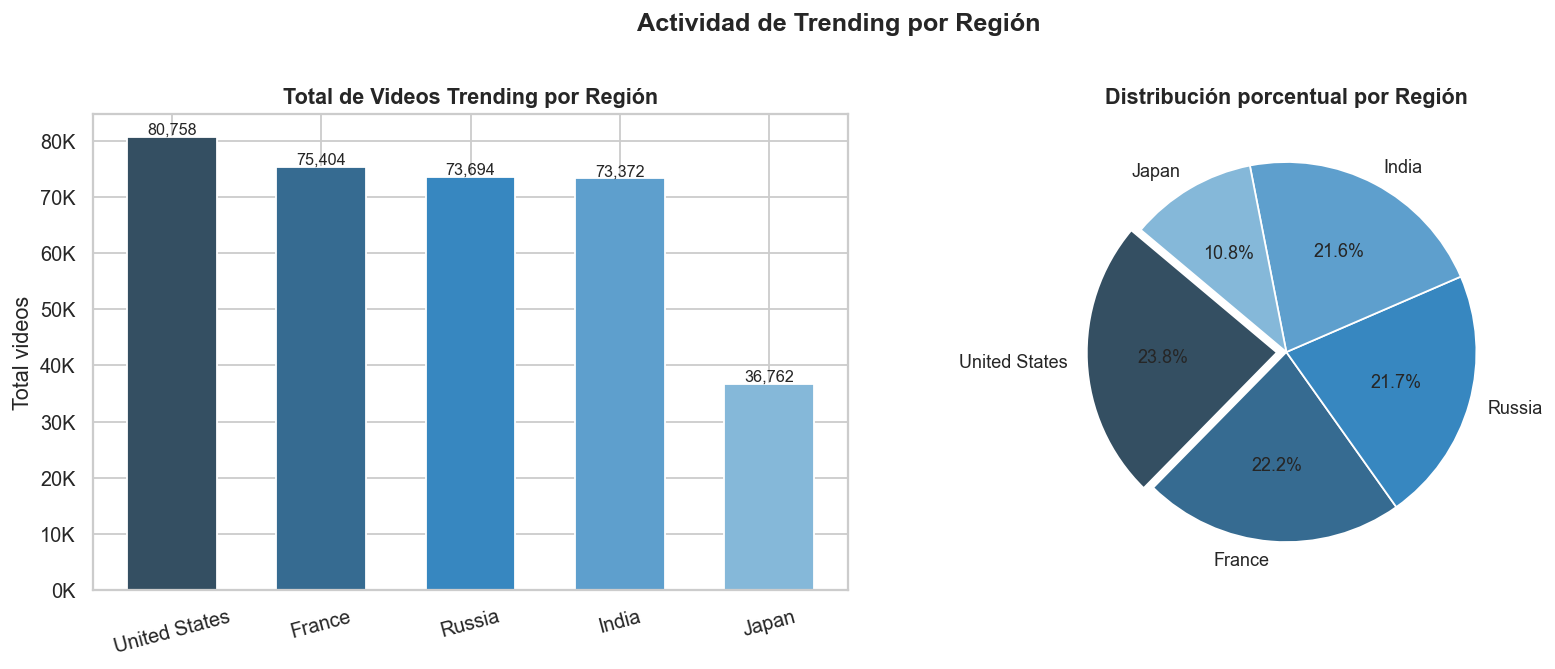

In [5]:
region_total = df.groupby('region')['videos_count'].sum().sort_values(ascending=False)
palette = sns.color_palette('Blues_d', len(region_total))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].bar(region_total.index, region_total.values,
                   color=palette[::-1], edgecolor='white', width=0.6)
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 500,
                 f'{h:,.0f}', ha='center', fontsize=9)
axes[0].set_title('Total de Videos Trending por Región', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Total videos')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[0].tick_params(axis='x', rotation=15)

explode = [0.05 if v == region_total.max() else 0 for v in region_total.values]
axes[1].pie(region_total.values, labels=region_total.index,
            autopct='%1.1f%%', colors=palette[::-1],
            explode=explode, startangle=140, textprops={'fontsize': 10})
axes[1].set_title('Distribución porcentual por Región', fontweight='bold', fontsize=12)

plt.suptitle('Actividad de Trending por Región', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

###  Análisis

La distribución por región muestra un escenario **sorprendentemente equilibrado** entre cuatro de los cinco mercados. **United States** lidera con 80.758 videos (23,7%), seguido muy de cerca por **France** (75.404 – 22,1%), **Russia** (73.694 – 21,6%) e **India** (73.372 – 21,5%). Estas cuatro regiones están separadas por apenas ~7.000 videos, lo que indica una actividad de Trending muy pareja.

El dato más llamativo es el de **Japan**, que con 36.762 videos (10,8%) queda notablemente por debajo del resto, representando menos de la mitad del volumen de Estados Unidos. Esto podría explicarse por el consumo de plataformas locales de video más arraigadas en Japón, o por un comportamiento de consumo más fragmentado entre plataformas.

El hecho de que India, uno de los mercados de YouTube de más rápido crecimiento en ese período, esté al mismo nivel que Europa y Rusia, confirma la expansión masiva de la plataforma en el subcontinente asiático durante 2017-2018.

---
## 6. Evolución temporal: ¿Cómo varió el Trending mes a mes?

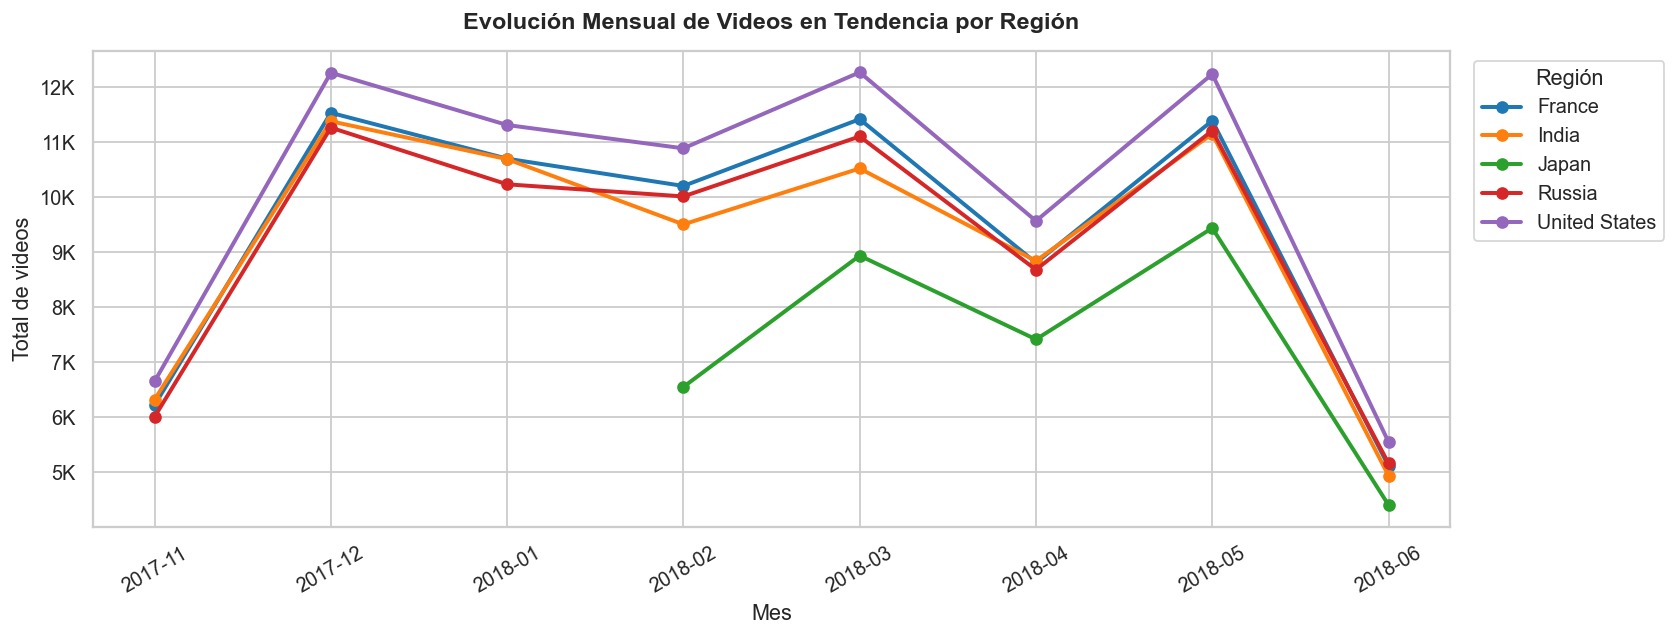

In [6]:
monthly = df.groupby(['month', 'region'])['videos_count'].sum().reset_index()
pivot = monthly.sort_values('month').pivot_table(index='month', columns='region', values='videos_count', aggfunc='sum')
colors_line = sns.color_palette('tab10', pivot.shape[1])

fig, ax = plt.subplots(figsize=(13, 5))
for i, region in enumerate(pivot.columns):
    ax.plot(pivot.index.astype(str), pivot[region],
            marker='o', linewidth=2.2, label=region, color=colors_line[i])

ax.set_title('Evolución Mensual de Videos en Tendencia por Región',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Mes')
ax.set_ylabel('Total de videos')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.legend(title='Región', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

###  Análisis

La evolución temporal es quizás el gráfico más rico en información. Se identifican **tres patrones clave**:

** El pico de diciembre 2017:** France, India y Russia alcanzan sus máximos históricos en diciembre 2017 (11.536, 11.382 y 11.266 videos respectivamente). Este pico coincide con la temporada navideña y fin de año, período en que el consumo de contenido en streaming se dispara a nivel global. Es un efecto estacional claro y consistente.

** La caída de enero 2018:** Inmediatamente después del pico de diciembre, casi todas las regiones experimentan una bajada significativa. Este comportamiento es clásico en series temporales de entretenimiento: el consumo post-festivo cae hasta que los hábitos se estabilizan.

** El repunte de United States en marzo 2018:** Estados Unidos muestra su pico más alto en marzo 2018 (12.272 videos), a diferencia del resto de regiones. Esto podría estar relacionado con eventos culturales del primer trimestre como los Premios Óscar o el inicio de la temporada de lanzamientos del entretenimiento americano.

**Japan** mantiene una línea consistentemente más baja a lo largo de todo el período, pero con una tendencia al alza hacia mayo-junio 2018, lo que podría indicar un crecimiento progresivo del uso de YouTube en ese mercado.

---
## 7. Heatmap: Categoría vs Región

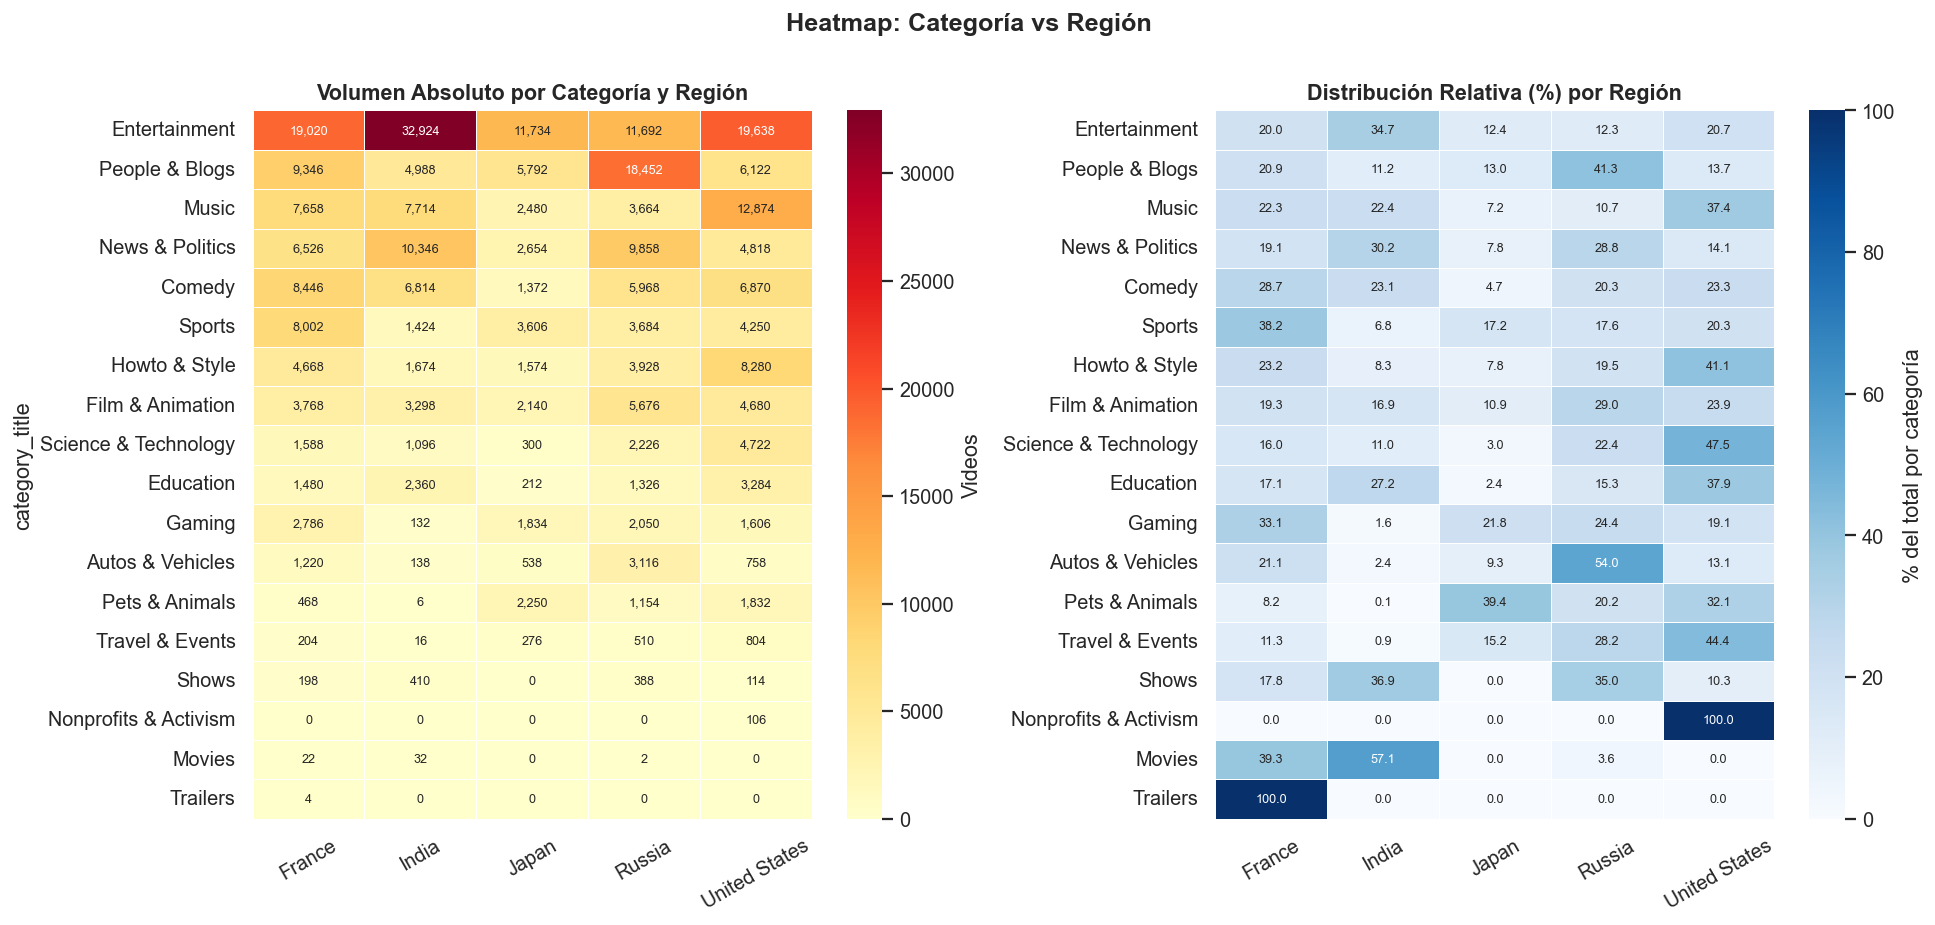

In [7]:
heat_data = df.pivot_table(index='category_title', columns='region',
                           values='videos_count', aggfunc='sum').fillna(0)
heat_norm = heat_data.div(heat_data.sum(axis=1), axis=0) * 100
heat_norm = heat_norm.loc[heat_data.sum(axis=1).sort_values(ascending=False).index]

def make_annot(data, fmt):
    return data.map(lambda v: f'{v:{fmt}}')

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

sns.heatmap(heat_data.loc[heat_norm.index], ax=axes[0], cmap='YlOrRd',
            annot=make_annot(heat_data.loc[heat_norm.index], ',.0f'),
            fmt='', annot_kws={'size': 7}, linewidths=0.4, cbar_kws={'label': 'Videos'})
axes[0].set_title('Volumen Absoluto por Categoría y Región', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

sns.heatmap(heat_norm.round(1), ax=axes[1], cmap='Blues',
            annot=make_annot(heat_norm.round(1), '.1f'),
            fmt='', annot_kws={'size': 7}, linewidths=0.4,
            cbar_kws={'label': '% del total por categoría'})
axes[1].set_title('Distribución Relativa (%) por Región', fontweight='bold')
axes[1].set_ylabel('')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Heatmap: Categoría vs Región', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

###  Análisis

El heatmap doble —absoluto y relativo— permite revelar algo que los gráficos anteriores no muestran: **las preferencias culturales locales**.

**Entertainment** domina en todas las regiones, pero su peso porcentual varía entre países. En algunos mercados representa más de un tercio del Trending total, mientras que en Rusia tiene menos protagonismo relativo.

**Russia** es la región con el comportamiento más diferenciado: es el único mercado donde **People & Blogs** desplaza a Entertainment como categoría número uno. Esto refleja la fuerte cultura de vlogs y creadores de contenido personal en la audiencia rusa de YouTube.

**Japan** muestra concentración elevada en pocas categorías (Entertainment y Music acumulan una porción desproporcionada), lo que sugiere preferencias más homogéneas o menor diversidad de creadores en Trending.

**News & Politics** tiene presencia notable en **United States** y **France**, probablemente reflejando el clima político de 2017-2018 en ambos países (primer año de la presidencia Trump y el período post-electoral en Francia).

Categorías como **Trailers**, **Shows** y **Movies** tienen su masa prácticamente concentrada en **United States**, lo que tiene sentido dado que la industria cinematográfica y televisiva global tiene su epicentro allí.

---
## 8. Top 5 categorías por región

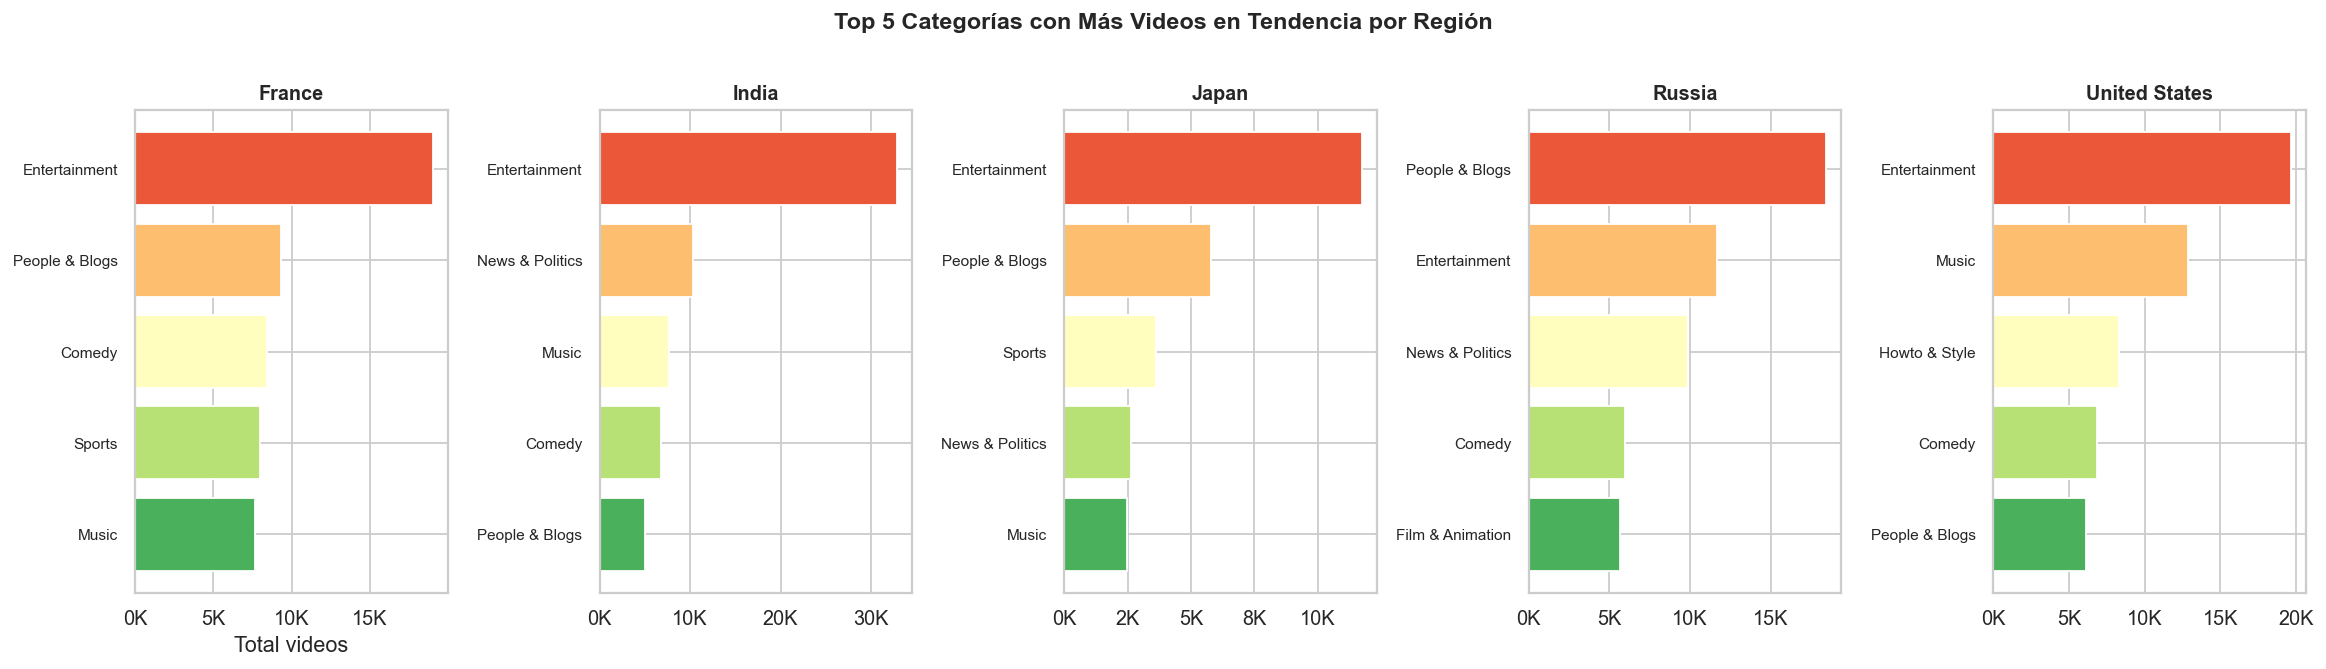

In [8]:
regions = sorted(df['region'].unique())
fig, axes = plt.subplots(1, 5, figsize=(18, 5), sharey=False)
colors_bar = sns.color_palette('RdYlGn_r', 5)

for i, region in enumerate(regions):
    top5 = (df[df['region'] == region]
            .groupby('category_title')['videos_count']
            .sum()
            .sort_values(ascending=False)
            .head(5))
    axes[i].barh(top5.index[::-1], top5.values[::-1],
                 color=colors_bar, edgecolor='white')
    axes[i].set_title(region, fontweight='bold', fontsize=11)
    axes[i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
    axes[i].tick_params(axis='y', labelsize=8.5)
    if i == 0:
        axes[i].set_xlabel('Total videos')

plt.suptitle('Top 5 Categorías con Más Videos en Tendencia por Región',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

###  Análisis

Este gráfico complementa al heatmap y permite ver con mayor claridad **quién lidera en cada mercado**.

**Francia** presenta un top 5 balanceado y diverso, con Entertainment al frente pero seguido de cerca por Music, Comedy y News & Politics. La presencia de Comedy entre los primeros puestos sugiere una audiencia con alto consumo de contenido ligero y cotidiano.

**India** también lidera con Entertainment, pero tiene una particularidad: **Music** ocupa un lugar muy destacado, coherente con la industria musical de Bollywood y la música regional, que genera contenido viral masivo en YouTube.

**Japan** es el mercado más atípico del grupo: categorías como **Science & Technology** y **Howto & Style** aparecen entre los primeros puestos, algo que no ocurre en ningún otro mercado. Esto refleja la reputación de Japón como mercado tech-forward con consumidores interesados en tutoriales y contenido educativo-tecnológico.

**Russia** es el único mercado con **People & Blogs** en el primer lugar, con un margen considerable sobre Entertainment. Además, **News & Politics** tiene una fuerte presencia, posiblemente influenciada por el contexto político de 2017-2018.

**United States** tiene el top 5 más concentrado, con Entertainment muy por encima del resto, y es el único mercado donde aparece **Film & Animation** en el ranking.

---
## 9. Distribución estadística de `videos_count`

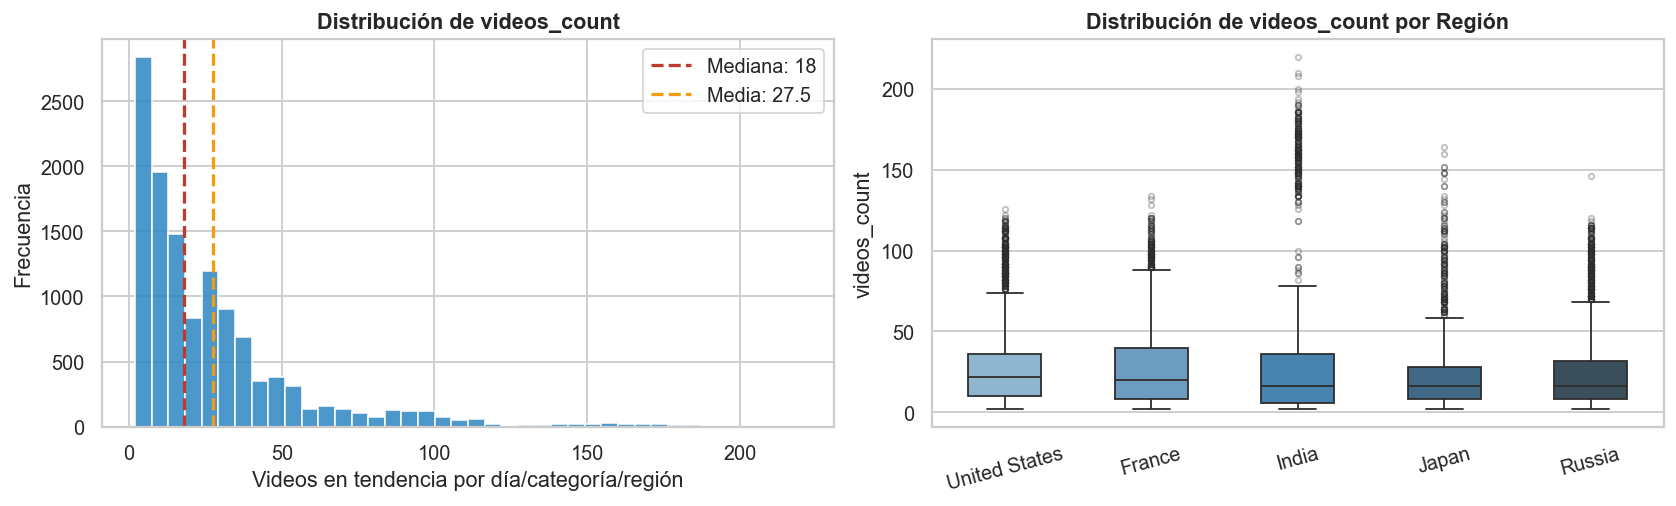

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['videos_count'], bins=40, color='#2e86c1', edgecolor='white', alpha=0.85)
axes[0].axvline(df['videos_count'].median(), color='#c0392b', linestyle='--',
                linewidth=1.8, label=f'Mediana: {df["videos_count"].median():.0f}')
axes[0].axvline(df['videos_count'].mean(), color='#f39c12', linestyle='--',
                linewidth=1.8, label=f'Media: {df["videos_count"].mean():.1f}')
axes[0].legend()
axes[0].set_title('Distribución de videos_count', fontweight='bold')
axes[0].set_xlabel('Videos en tendencia por día/categoría/región')
axes[0].set_ylabel('Frecuencia')

order = df.groupby('region')['videos_count'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='region', y='videos_count', order=order,
            palette='Blues_d', ax=axes[1], width=0.5,
            flierprops=dict(marker='o', markersize=3, alpha=0.3))
axes[1].set_title('Distribución de videos_count por Región', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('videos_count')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

###  Análisis

La distribución de `videos_count` tiene una forma característica de **cola larga hacia la derecha** (*right-skewed*), con un coeficiente de asimetría de **2.33**, lo que indica una desviación importante respecto a la normalidad.

La **mediana (18)** es considerablemente más baja que la **media (27.5)**, lo que confirma el sesgo: la mayoría de las combinaciones de fecha/región/categoría registran entre 2 y 36 videos en tendencia, pero existen casos puntuales que se disparan hasta **220 videos** en un solo día. Estos valores extremos —probablemente eventos muy específicos como finales deportivas, premieres globales o eventos políticos de impacto— inflan la media significativamente.

En el boxplot por región, **United States** tiene la mediana más alta y también la mayor dispersión en outliers, reflejando tanto el volumen de su mercado como la variabilidad de eventos que generan picos de contenido viral. **Japan**, en contraste, muestra la distribución más compacta, coherente con su menor actividad general en Trending.

Para análisis futuros, este sesgo sugiere que sería conveniente trabajar con transformaciones logarítmicas de `videos_count` si se busca modelar esta variable, o considerar la mediana como medida de tendencia central en lugar de la media.

---
## 10. Conclusiones 

Este análisis exploratorio del dataset de YouTube Trending permite extraer hallazgos relevantes tanto sobre el comportamiento global de la plataforma como sobre las particularidades de cada mercado regional.

###  Entertainment: el contenido sin fronteras
**Entertainment** es, con casi 95.000 videos acumulados, la categoría que domina Trending en todos los mercados sin excepción —excepto Rusia—. Su participación del 27,9% sobre el total global la convierte en una clase propia, más del doble que la segunda. Esto refleja que el entretenimiento generalista tiene una capacidad de viralización transversal que ninguna otra categoría puede igualar en YouTube.

###  Cuatro mercados parejos, uno rezagado
Sorprendentemente, cuatro de las cinco regiones analizadas (EE.UU., Francia, Rusia e India) muestran volúmenes de Trending muy similares (~73.000–80.000 videos cada una). **Japón** se desmarca notablemente hacia abajo con tan solo 36.762 videos, menos de la mitad que el líder. Esta brecha podría explicarse por un ecosistema digital diferente y por hábitos de consumo más diversificados entre plataformas locales.

###  La estacionalidad importa
El análisis temporal revela que **diciembre de 2017** fue el mes de mayor actividad para la mayoría de las regiones, un patrón estacional claro asociado al período festivo de fin de año. La excepción es **Estados Unidos**, cuyo pico ocurrió en **marzo de 2018**, posiblemente impulsado por eventos como los premios cinematográficos y estrenos de la industria del entretenimiento americano.

###  Rusia: el mercado de los creadores de contenido personal
Rusia es el único mercado donde **People & Blogs** supera a Entertainment, lo que lo convierte en un caso único dentro del dataset. La cultura del vlog y el contenido de creadores independientes está profundamente arraigada en la audiencia rusa de YouTube, diferenciándola claramente del resto de los mercados analizados.

###  India y la fuerza de la música
India sobresale por el peso de **Music** en su Trending, un reflejo directo de la industria musical de Bollywood y la música regional, que genera contenido masivamente viral en YouTube. Este mercado se consolida como uno de los más activos en consumo musical digital del período analizado.

###  Una distribución con picos excepcionales
Estadísticamente, `videos_count` presenta una distribución sesgada a la derecha (asimetría de 2.33): la mayoría de los días/categorías/regiones registran entre **2 y 36 videos** en Trending, pero existen eventos puntuales que generan picos de hasta **220 videos** en un solo día. Estos outliers no son ruido, sino señales de eventos culturales de alto impacto que merecen análisis específico.

---